In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

df = pd.read_csv(
    "/content/drive/MyDrive/HireShield/data/master_dataset.csv"
)

print(df.shape)
df.head()


Mounted at /content/drive
(27880, 10)


,title,description,requirements,company_profile,location,salary_range,employment_type,industry,benefits,fraudulent
0,Marketing Intern,"Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,"We're Food52, and we've created a groundbreaki...","US, NY, New York",NaN,Other,NaN,NaN,0
1,Customer Service - Cloud Video Production,Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,"90 Seconds, the worlds Cloud Video Production ...","NZ, , Auckland",NaN,Full-time,Marketing and Advertising,What you will get from usThrough being part of...,0
2,Commissioning Machinery Assistant (CMA),"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,Valor Services provides Workforce Solutions th...,"US, IA, Wever",NaN,NaN,NaN,NaN,0
3,Account Executive - Washington DC,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our passion for improving quality of life thro...,"US, DC, Washington",NaN,Full-time,Computer Software,Our culture is anything but corporate—we have ...,0
4,Bill Review Manager,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,SpotSource Solutions LLC is a Global Human Cap...,"US, FL, Fort Worth",NaN,Full-time,Hospital & Health Care,Full Benefits Offered,0


In [ ]:
df[['title', 'description', 'requirements', 'company_profile']].isnull().sum()


,0
title,0
description,1
requirements,2696
company_profile,3308


In [ ]:
df = df.fillna("")


In [ ]:
df[['title', 'description', 'requirements', 'company_profile']].isnull().sum()


,0
title,0
description,0
requirements,0
company_profile,0


In [ ]:
df.head()

,title,description,requirements,company_profile,location,salary_range,employment_type,industry,benefits,fraudulent
0,Marketing Intern,"Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,"We're Food52, and we've created a groundbreaki...","US, NY, New York",,Other,,,0
1,Customer Service - Cloud Video Production,Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,"90 Seconds, the worlds Cloud Video Production ...","NZ, , Auckland",,Full-time,Marketing and Advertising,What you will get from usThrough being part of...,0
2,Commissioning Machinery Assistant (CMA),"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,Valor Services provides Workforce Solutions th...,"US, IA, Wever",,,,,0
3,Account Executive - Washington DC,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our passion for improving quality of life thro...,"US, DC, Washington",,Full-time,Computer Software,Our culture is anything but corporate—we have ...,0
4,Bill Review Manager,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,SpotSource Solutions LLC is a Global Human Cap...,"US, FL, Fort Worth",,Full-time,Hospital & Health Care,Full Benefits Offered,0


In [ ]:
df['text'] = (
    df['title'] + " " +
    df['description'] + " " +
    df['requirements'] + " " +
    df['company_profile']
)


In [ ]:
df[['text', 'fraudulent']].head()


,text,fraudulent
0,"Marketing Intern Food52, a fast-growing, James...",0
1,Customer Service - Cloud Video Production Orga...,0
2,Commissioning Machinery Assistant (CMA) Our cl...,0
3,Account Executive - Washington DC THE COMPANY:...,0
4,Bill Review Manager JOB TITLE: Itemization Rev...,0


In [ ]:
from sklearn.model_selection import train_test_split

X = df['text']
y = df['fraudulent']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (22304,)
Test size: (5576,)


In [ ]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# quick sanity check
sample = X_train.iloc[0]
tokens = tokenizer.tokenize(sample)

print("Sample text (first 200 chars):")
print(sample[:200])

print("\nTokenized output:")
print(tokens[:20])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Sample text (first 200 chars):
Engineer, water Factor table phone Democrat crime science. Earn $5000/week! Immediate hiring. Contact now at brendalopez@arroyo-cordova.org. Basic knowledge in produce, no degree required. Flexible ho

Tokenized output:
['engineer', ',', 'water', 'factor', 'table', 'phone', 'democrat', 'crime', 'science', '.', 'earn', '$', '5000', '/', 'week', '!', 'immediate', 'hiring', '.', 'contact']


In [ ]:
# Encode train data
train_encodings = tokenizer(
    X_train.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

# Encode test data
test_encodings = tokenizer(
    X_test.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

# Sanity check
print("Train input_ids shape:", len(train_encodings['input_ids']))
print("Test input_ids shape:", len(test_encodings['input_ids']))


Train input_ids shape: 22304
Test input_ids shape: 5576


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words='english'
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred_lr = lr_model.predict(X_test_tfidf)

In [ ]:
print("="*50)
print("LOGISTIC REGRESSION BASELINE RESULTS")
print("="*50)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr,
      target_names=['Real Job', 'Fake Job']))

LOGISTIC REGRESSION BASELINE RESULTS
Accuracy: 0.9826040172166427

Classification Report:

              precision    recall  f1-score   support

    Real Job       0.97      1.00      0.99      3403
    Fake Job       1.00      0.96      0.98      2173

    accuracy                           0.98      5576
   macro avg       0.99      0.98      0.98      5576
weighted avg       0.98      0.98      0.98      5576



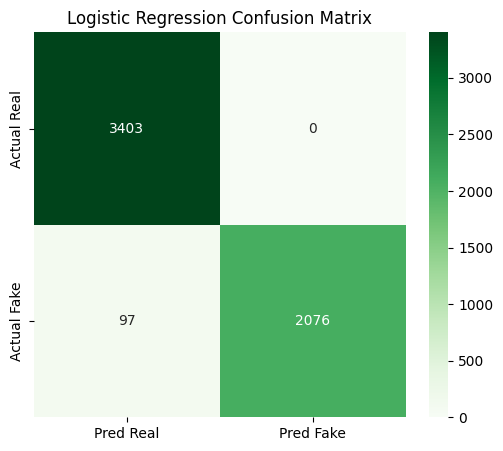

In [ ]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Pred Real', 'Pred Fake'],
            yticklabels=['Actual Real', 'Actual Fake'])
plt.title('Logistic Regression Confusion Matrix')
plt.show()

In [ ]:
import torch
from torch.utils.data import Dataset


In [ ]:
class JobDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels.iloc[idx])
        return item


In [ ]:
train_dataset = JobDataset(train_encodings, y_train)
test_dataset = JobDataset(test_encodings, y_test)

print("Train dataset size:", len(train_dataset))
print("Test dataset size:", len(test_dataset))


Train dataset size: 22304
Test dataset size: 5576


In [ ]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
import torch

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)

print("Using device:", device)


Using device: cuda


In [ ]:
eval_strategy="epoch",


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
)


`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, predictions)
    return {"accuracy": acc}


In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)


In [ ]:
trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy
1,0.106854,0.060488,0.986011
2,0.063830,0.057131,0.988881


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=5576, training_loss=0.06922090934373043, metrics={'train_runtime': 1227.8278, 'train_samples_per_second': 36.331, 'train_steps_per_second': 4.541, 'total_flos': 2934214489374720.0, 'train_loss': 0.06922090934373043, 'epoch': 2.0})

In [ ]:
eval_results = trainer.evaluate()
print(eval_results)


{'eval_loss': 0.057130735367536545, 'eval_accuracy': 0.9888809182209469, 'eval_runtime': 41.898, 'eval_samples_per_second': 133.085, 'eval_steps_per_second': 16.636, 'epoch': 2.0}


In [ ]:
trainer.save_model("/content/drive/MyDrive/HireShield/bert_model")
tokenizer.save_pretrained("/content/drive/MyDrive/HireShield/bert_model")



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/HireShield/bert_model/tokenizer_config.json',
 '/content/drive/MyDrive/HireShield/bert_model/tokenizer.json')

In [ ]:
import os
os.listdir("/content/drive/MyDrive/HireShield/bert_model")


['config.json',
 'tokenizer.json',
 'training_args.bin',
 'tokenizer_config.json',
 'model.safetensors']

In [ ]:
text = """
Urgent hiring! Earn $4000 per week working from home.
No experience needed. Contact HR immediately via WhatsApp.
"""

inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs)
    probs = torch.softmax(outputs.logits, dim=1)

print("Real job probability:", probs[0][0].item())
print("Fake job probability:", probs[0][1].item())


Real job probability: 2.7821713956655003e-05
Fake job probability: 0.9999722242355347


In [ ]:
text = """
Marketing Manager at Google Inc.
Location: Mountain View, CA. Full-time position.
Requirements: 5+ years experience, MBA preferred.
Excellent benefits package. Apply through careers.google.com
"""
inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
inputs = {k: v.to(device) for k, v in inputs.items()}
with torch.no_grad():
    outputs = model(**inputs)
    probs = torch.softmax(outputs.logits, dim=1)
print(f"Real: {probs[0][0].item():.4f}, Fake: {probs[0][1].item():.4f}")

Real: 0.9949, Fake: 0.0051


In [ ]:
text = """
Software Engineer position at TechCorp.
Salary: $150,000/year. Remote work available.
Please send resume to hiring@gmail.com
"""
inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
inputs = {k: v.to(device) for k, v in inputs.items()}
with torch.no_grad():
    outputs = model(**inputs)
    probs = torch.softmax(outputs.logits, dim=1)
print(f"Real: {probs[0][0].item():.4f}, Fake: {probs[0][1].item():.4f}")

Real: 0.0003, Fake: 0.9997


In [ ]:
text = """
Entry level position. Training provided.
Flexible schedule. Good growth opportunities.
"""
inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
inputs = {k: v.to(device) for k, v in inputs.items()}
with torch.no_grad():
    outputs = model(**inputs)
    probs = torch.softmax(outputs.logits, dim=1)
print(f"Real: {probs[0][0].item():.4f}, Fake: {probs[0][1].item():.4f}")

Real: 0.0001, Fake: 0.9999


In [ ]:
text = """
Barista needed at Sunrise Coffee Shop.
$15/hour, flexible hours, free coffee and meals!
Experience preferred but will train the right person.
Come by the shop to apply: 123 Main Street, Downtown.
"""
inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
inputs = {k: v.to(device) for k, v in inputs.items()}
with torch.no_grad():
    outputs = model(**inputs)
    probs = torch.softmax(outputs.logits, dim=1)
print(f"Real: {probs[0][0].item():.4f}, Fake: {probs[0][1].item():.4f}")

Real: 0.9940, Fake: 0.0060


In [ ]:
text = """
Crypto Trading Assistant needed immediately!
Earn up to $8000 weekly! No investment required.
WhatsApp +1-555-CRYPTO now! Limited spots available!
Act fast before positions fill up!
"""
inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
inputs = {k: v.to(device) for k, v in inputs.items()}
with torch.no_grad():
    outputs = model(**inputs)
    probs = torch.softmax(outputs.logits, dim=1)
print(f"Real: {probs[0][0].item():.4f}, Fake: {probs[0][1].item():.4f}")

Real: 0.0001, Fake: 0.9999


In [ ]:
trainer.save_model("/content/drive/MyDrive/HireShield/bert_model")
tokenizer.save_pretrained("/content/drive/MyDrive/HireShield/bert_model")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/HireShield/bert_model/tokenizer_config.json',
 '/content/drive/MyDrive/HireShield/bert_model/tokenizer.json')

In [ ]:
import os
os.listdir("/content/drive/MyDrive/HireShield/bert_model")


['config.json',
 'model.safetensors',
 'training_args.bin',
 'tokenizer_config.json',
 'tokenizer.json']

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Real Job       0.99      0.99      0.99      3403
    Fake Job       0.99      0.98      0.99      2173

    accuracy                           0.99      5576
   macro avg       0.99      0.99      0.99      5576
weighted avg       0.99      0.99      0.99      5576


Confusion Matrix Values:
[[3385   18]
 [  44 2129]]


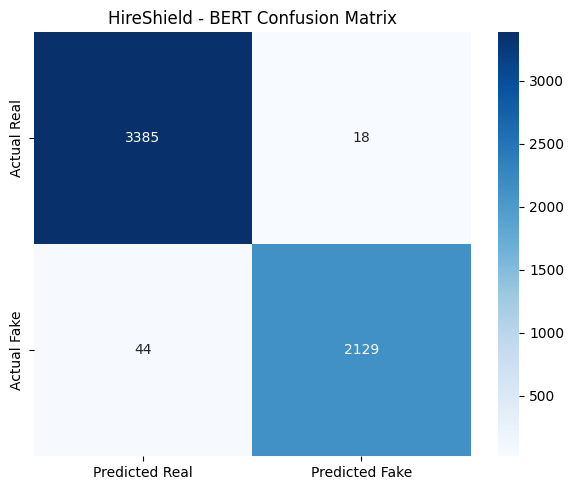

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Get predictions
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

print("=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_true, y_pred,
      target_names=['Real Job', 'Fake Job']))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

print("\nConfusion Matrix Values:")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Real', 'Predicted Fake'],
            yticklabels=['Actual Real', 'Actual Fake'])

plt.title('HireShield - BERT Confusion Matrix')
plt.tight_layout()

plt.savefig("/content/drive/MyDrive/HireShield/confusion_matrix.png")
plt.show()

AUC Score: 0.9970029287116927


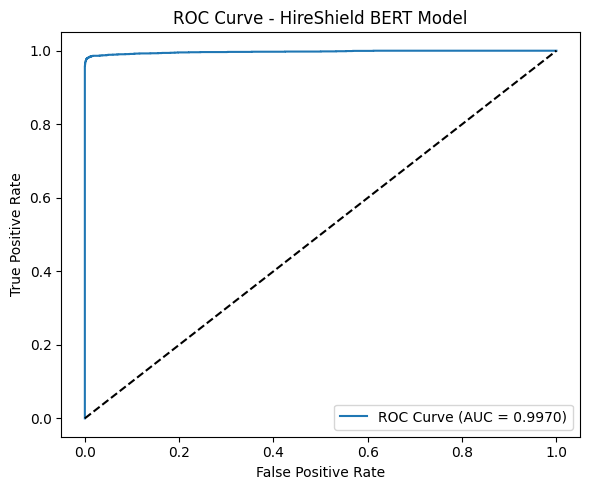

In [ ]:
from sklearn.metrics import roc_curve, auc

# Get probability scores for Fake class (class index 1)
y_probs = torch.softmax(torch.tensor(predictions.predictions), dim=1)[:, 1].numpy()

fpr, tpr, thresholds = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0,1], [0,1], 'k--')  # diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - HireShield BERT Model')
plt.legend(loc="lower right")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/HireShield/roc_curve.png")
plt.show()

Average Precision (AP): 0.9968276290964281


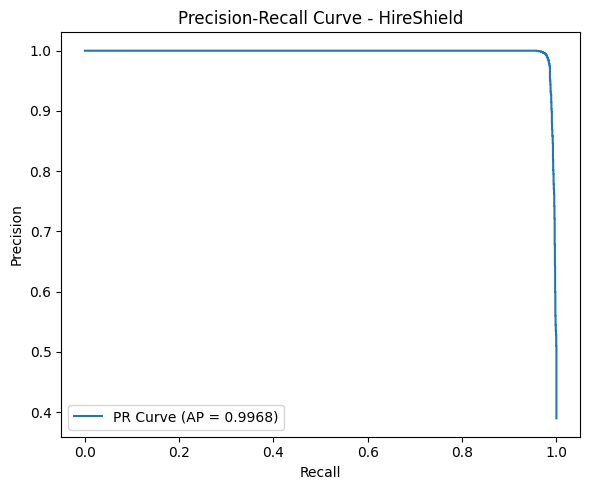

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_true, y_probs)
ap_score = average_precision_score(y_true, y_probs)

print("Average Precision (AP):", ap_score)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - HireShield')
plt.legend()

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/HireShield/pr_curve.png")
plt.show()